In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Fishers maket.csv")

In [3]:
df.head(5)

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 9.6 KB


In [5]:
df.shape

(159, 7)

In [6]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [7]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='str')

In [8]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le=LabelEncoder()

In [12]:
df["Species"]=le.fit_transform(df["Species"])

In [13]:
df.head(5)

,Species,Weight,Length1,Length2,Length3,Height,Width
0,0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,0,290.0,24.0,26.3,31.2,12.4800,4.3056
2,0,340.0,23.9,26.5,31.1,12.3778,4.6961
3,0,363.0,26.3,29.0,33.5,12.7300,4.4555
4,0,430.0,26.5,29.0,34.0,12.4440,5.1340


In [14]:
df["Species"].unique()

array([0, 4, 6, 1, 2, 3, 5])

In [15]:
x=df.drop("Species",axis=1)

In [16]:
y=df["Species"]

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
model=DecisionTreeClassifier(random_state=42)

In [21]:
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [22]:
y_pred=model.predict(x_test)

In [23]:
y_pred

array([2, 5, 3, 4, 4, 0, 5, 4, 4, 3, 0, 6, 0, 1, 0, 0, 2, 4, 4, 0, 5, 0,
       0, 0, 0, 2, 4, 4, 5, 5, 3, 2])

In [24]:
model.score(x_test,y_test)*100

78.125

In [25]:
x_train,y_train


(     Weight  Length1  Length2  Length3   Height   Width
 75     51.5     15.0     16.2     17.2   4.5924  2.6316
 138   567.0     43.2     46.0     48.7   7.7920  4.8700
 2     340.0     23.9     26.5     31.1  12.3778  4.6961
 86    120.0     20.0     22.0     23.5   6.1100  3.4075
 45    160.0     20.5     22.5     25.3   7.0334  3.8203
 ..      ...      ...      ...      ...      ...     ...
 71    300.0     24.0     26.0     29.0  11.3680  4.2340
 106   250.0     25.9     28.0     29.4   7.8204  4.2042
 14    600.0     29.4     32.0     37.2  14.9544  5.1708
 92    150.0     20.5     22.5     24.0   6.7920  3.6240
 102   300.0     25.2     27.3     28.7   8.3230  5.1373
 
 [127 rows x 6 columns],
 75     2
 138    3
 2      0
 86     2
 45     4
       ..
 71     1
 106    2
 14     0
 92     2
 102    2
 Name: Species, Length: 127, dtype: int64)

In [27]:
model.predict([[51.5,15.0,16.2,17.2,4.5924,2.6316]])

C:\Users\agraw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([2])

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy=accuracy_score(y_test,y_pred)

In [30]:
accuracy

0.78125

In [31]:
from sklearn.metrics import confusion_matrix

In [32]:
cm=confusion_matrix(y_test,y_pred)

In [33]:
cm

array([[10,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  4,  0,  5,  0,  0],
       [ 0,  0,  0,  3,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  5,  0],
       [ 0,  0,  0,  0,  2,  0,  1]])

In [34]:
from sklearn.metrics import classification_report

In [35]:
cr=classification_report(y_test,y_pred)

In [36]:
cr

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        10\n           1       1.00      1.00      1.00         1\n           2       1.00      0.44      0.62         9\n           3       1.00      1.00      1.00         3\n           4       0.12      1.00      0.22         1\n           5       1.00      1.00      1.00         5\n           6       1.00      0.33      0.50         3\n\n    accuracy                           0.78        32\n   macro avg       0.88      0.83      0.76        32\nweighted avg       0.97      0.78      0.82        32\n'

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

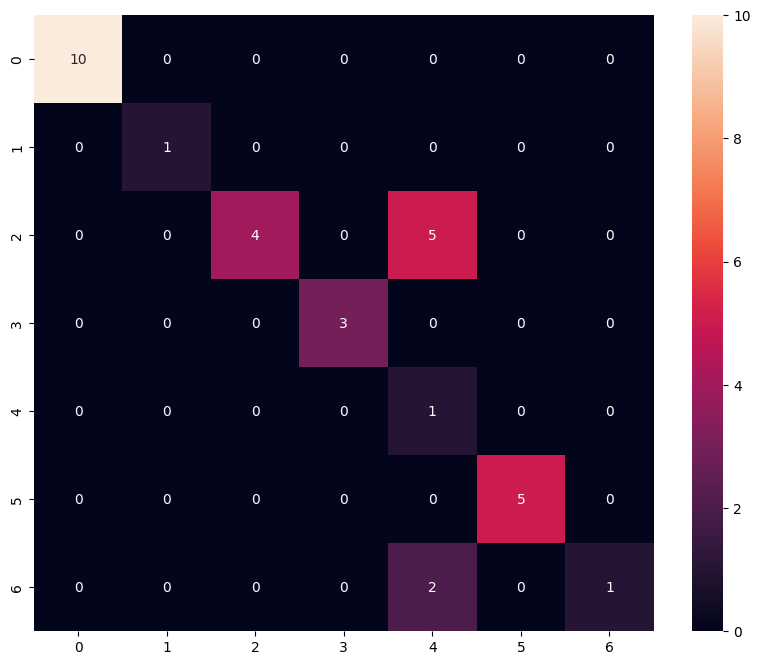

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True)
plt.show()